--- Initial Null Count ---
YEAR                   0
MO                     0
DY                     0
RH2M                   0
T2MDEW                 0
QV2M                   0
PS                     0
WS50M                  0
PRECTOTCORR            0
T2MWET                 0
WD50M                  0
T2M_MAX                0
T2M_MIN                0
ALLSKY_SFC_UV_INDEX    0
TS                     0
PSC                    0
WSC                    0
DISTRICT               0
LATITUDE               0
LONGITUDE              0
dtype: int64

Missing values after cleaning: 0

Random Forest R2 Score: 0.5987
MAE: 1.8149
RMSE: 4.7479
R2: 0.5987


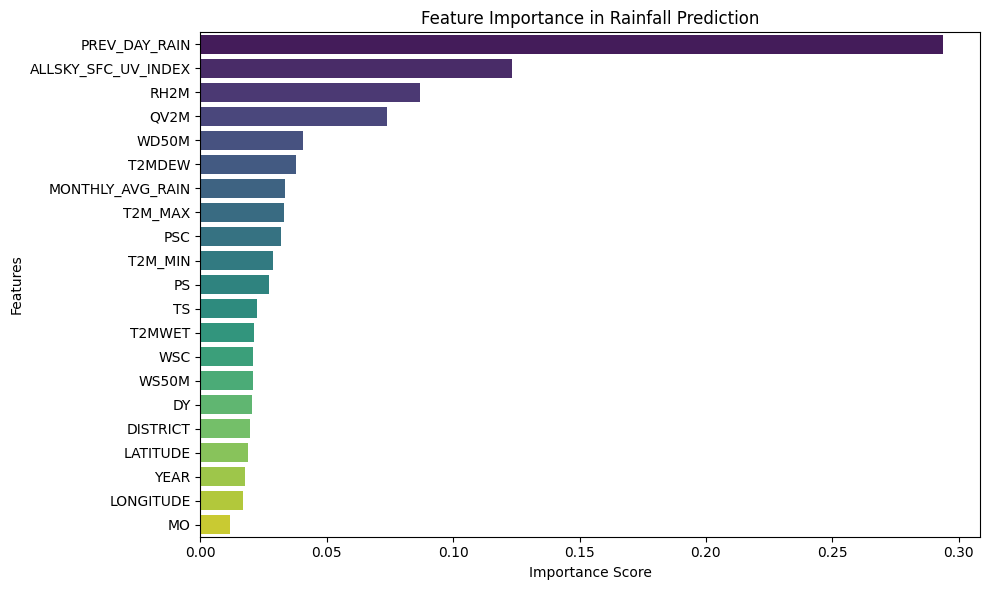

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. LOAD DATA
df = pd.read_csv('C:/Users/user/Downloads/UP_rainfall_dataset.csv')
df.columns = df.columns.str.strip()

# 2. NULL CHECK & CLEANING
print("--- Initial Null Count ---")
print(df.isnull().sum())

# Define numeric and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns

# Fill numeric NaNs with median
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Fill categorical NaNs with mode
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print(f"\nMissing values after cleaning: {df.isnull().sum().sum()}")

# 3. FEATURE ENGINEERING
# Create a temporal identifier
df = df.sort_values(['DISTRICT', 'YEAR', 'MO', 'DY'])
# Lag feature: Yesterday's rainfall
df['PREV_DAY_RAIN'] = df.groupby('DISTRICT')['PRECTOTCORR'].shift(1).fillna(0)
# Monthly trend feature
df['MONTHLY_AVG_RAIN'] = df.groupby(['DISTRICT', 'MO'])['PRECTOTCORR'].transform('mean')

# 4. ENCODING & SCALING
le = LabelEncoder()
df['DISTRICT'] = le.fit_transform(df['DISTRICT'])

# Sample 10% of the data to test your pipeline quickly
df_sample = df.sample(frac=0.1, random_state=42)
target = 'PRECTOTCORR'
X = df_sample.drop(columns=[target])
y = df_sample[target]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. SPLIT & TRAIN
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

lr = LinearRegression().fit(X_train, y_train)
# Use only 2 or 4 cores instead of all available
rf = RandomForestRegressor(n_estimators=50, n_jobs=2, random_state=42).fit(X_train, y_train)
print(f"\nRandom Forest R2 Score: {r2_score(y_test, rf.predict(X_test)):.4f}")

import matplotlib.pyplot as plt
import seaborn as sns

# Calculate detailed metrics
y_pred = rf.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")

# Visualize Feature Importance (The "Attractive" Part)
feature_names = X.columns
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importance in Rainfall Prediction")

sns.barplot(
    x=importances[indices],
    y=feature_names[indices],
    hue=feature_names[indices],
    palette="viridis",
    legend=False
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()